# Final *BSTA040 Data Exploration in Python*

*Instructions*: The goal for the final is to explore the multivariate normal distribution and its relationship to linear regression. Please treat this assignment similar to how you may treat an extended homework assignment with on exception. 

It is ok to ask me questions about the final. It is **NOT** ok to work together with others as you complete this assignment. 

The Final is due on the very last day that finals are administered at Lehigh for this semester by 11:59:59pm Eastern Standard Time. You are welcome to email me your final assignment or, preferably, upload it to course site. 


## Dataset 

Please load into your notebook the dataset called "final_dataset.csv". i'll refer to that dataset by the letter `d`. The dataset `d` contains two columns: The first column is called `season` and refers to successive influenza seasons. The second column is called `vac` and contains the total percent of the US population that was vaccinated against influenza. The third column contains the total number of US reported hospitalizations due to influenza. 


In [92]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

d = pd.read_csv("./final_data/flu_data.csv")

## 1. Exploratory data analysis 

Please use exploratory data analysis (EDA) technqiues to describe/summarize (a) total vaccination percentage over seasons and (b) total number of influenza hospitalizations over season. 
In addition, please use EDA techniques to describe the association between vaccination and hospitalizations at the US national level. 

Your response should include a collection of figures and textual description. 

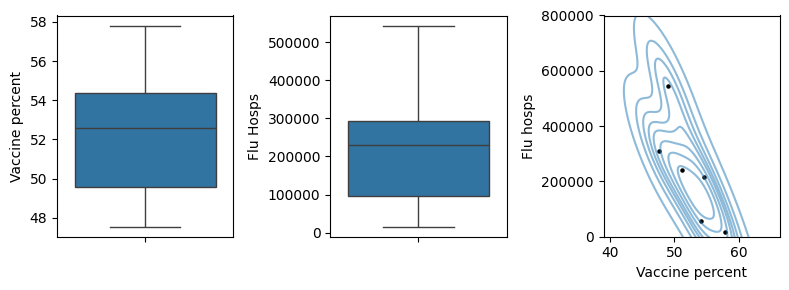

In [93]:
### 1. Answer




## 2. Multivariate Normal Density 

Lets use the multivariate normal (MVN) distribution to model the joint probability of vaccination and flu hospitalizations. That is, we will assume that each season of (vaccination, flu hospitalizations) was generated by a vector of random variables 

\begin{align}
    \begin{bmatrix}
       V \\
       F
    \end{bmatrix}_{s} \sim \text{MVN}( \mu_{2\times1}, \Sigma_{2\times2} )
\end{align}

Your goal will be to estimate the parameters $\mu$ and $\Sigma$ in this model. Please write python code to estimate $mu$ as 

\begin{align}
    \hat{\mu} = \frac{\mathbb{1}_{1 \times S} D_{S \times 2}}{S}
\end{align}

where $S$ is the number of seasons (ie the number of datapoints), $\mathbb{1}$ is a vector that contains one in each entry, and $D$ is the dataset with $S$ rows and two columns: the first column contains the percent vaccination and the second column contains the total number of hospitalizations. Call your estimate of $\mu$ the variable `mu_hat`. 

To estimate $\Sigma$, we will compute 

\begin{align}
    \hat{ \Sigma } = \frac{1}{S} \left( D_{S \times 2} - \hat{\mu}_{1 \times 2} \right)^{T} \left( D_{S \times 2} - \hat{\mu}_{1 \times 2} \right)
\end{align}

In [94]:
## 2. Answer


Mu hat
[[    52.34 231026.  ]]
---------------
Sigma hat
[[ 1.21e+01 -4.87e+05]
 [-4.87e+05  3.02e+10]]


## 3. Visually assess model fit 

Let's assess how well this model fits our dataset $D$. 
We will simulate, from our MVN model above, 5000 points using `numpy.random.multivariate_normal` and store them in a dataset called `model_samples`. This samples dataset will have 5000 rows and two columns: the first column will correspond to vaccination and the second column to influenza hospitalizations. 

Create a seaborn joint plot (https://seaborn.pydata.org/generated/seaborn.jointplot.html) that specifes the argument `kind = kde`. 
Layer on top of this plot the observed (vaccination, hospitalization) points from our dataset D. 

Please comment on the Multivariate normal model, model-generated marginal densities, and whether you feel that this model first well to the data. 

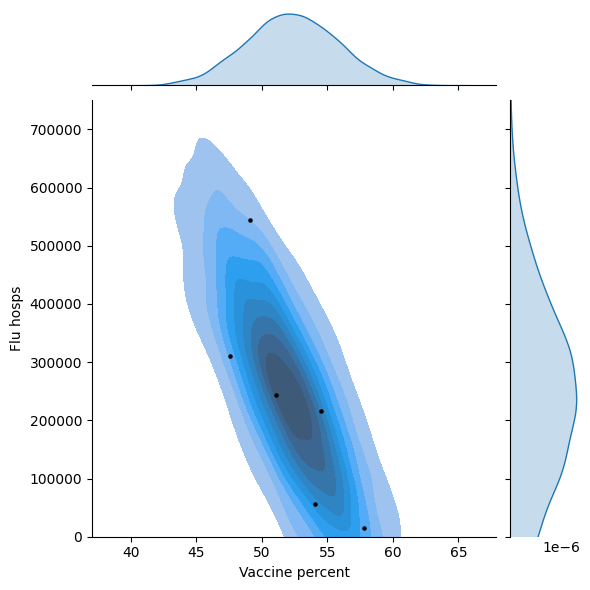

In [95]:
# 3. Answer




## 4. Correlation  

We estimated above the Covariance matrix. However, we know that the covariance and correlation between two random variables, $X$ and $Y$, are related by 

\begin{align}
    Corr(X,Y) = \frac{Cov(X,Y)}{ s(X) s(Y)  }
\end{align}

where Corr is the correlation between random variables X and Y, $s(X)$ is the standard deviation of $X$ or $\mathbb{V}(X)^{1/2}$, and $s(Y)$ is the standard deviation of $Y$ or $\mathbb{V}(Y)^{1/2}$.  

Given our estimated covariance matrix above, $\hat{\Sigma}$, please compute the correlation matrix in python using 

\begin{align}
    \begin{bmatrix}
        1/s(X) & 0 \\
         0         & 1/s(Y) 
    \end{bmatrix} 
    \hat{\Sigma}
    \begin{bmatrix}
        1/s(X) & 0 \\
         0         & 1/s(Y) 
    \end{bmatrix}
\end{align}

Please comment on the correlation matrix use this matrix to describe the relationship between vaccination and total number of influenza hospitalizations. 

In [96]:
# 4. Answer




## 5. Linear regression

Another *very common* model considers one variable fixed, focusing on uncertainity in just one other variable. The model we will consider is called **single covariate linear regression**. Single covariate linear regression assumes the following conditional distribution

\begin{align}
    Y_{i}|x_{i} \sim \mathcal{N}( \beta_{0} + \beta_{1} x_{i}, \sigma^{2} )
\end{align}

for all observations denoted by $i$; and where $\beta_{0}$ is typically called the model intercept, $\beta_{1}$ is typically called the model slope. The values $\beta_{0}, \beta_{1}$, and, this is important, $x_{i}$ are considered fixed/constant values.  

Lets focus on understanding the variation of the total number of influenza hospitalizations given a known, fixed vaccination percent. That is, in the above model we will consider hospitalizations the "Y" random variable and "x" the fixed, constant vaccine percentage.  

An alternative way to write down this model for all observations is 

\begin{align}
    Y_{S \times 1} \sim \text{MVN}\left( X \beta, \sigma^{2} I_{S \times S} \right)
\end{align}

where $S$ is the number of seasons of data that we have for influenza (ie the number of observations in our dataset), $\beta$ is the vector

\begin{align}
    \beta = \begin{bmatrix}
        \beta_{0} \\ 
        \beta_{1}
    \end{bmatrix}
\end{align}

and the matrix $X$ equals 

\begin{align}
    X = \begin{bmatrix}
    1 & f_{1} \\ 
    1 & f_{2} \\ 
    1 & f_{3} \\ 
    \vdots
    \end{bmatrix}
\end{align}

and the vector $Y$ equals 

\begin{align}
    Y = \begin{bmatrix}
    V_{1} \\ 
    V_{2} \\ 
    V_{3} \\ 
    \vdots
    \end{bmatrix}
\end{align}

**Please explain** why this matrix/vector representation is the same as the above representation that does not uses matrices or vectors. 

## 6. An estimate of the intercept and the slope
In supervised machine learning, you will learn that estimates for $\beta_{0}$ and $\beta_{1}$ are  

\begin{align}
    \hat{\beta} = \left(X^{T}X\right)^{-1}Xy 
\end{align}

where $X_{S \times 2}$ is the above matrix that has a column of ones and a second column of, in our case, vaccine percentages; and the vector $y_{S \times 1}$ is a vector of, in our case, the total number of influenza hospitalizations. 

Please estimate the vector $\beta = [\beta_{0}, \beta_{1}]^{T}$ in python by forming the matirx X, the vector y, and using the above matrix formula. Call this estimated vector the variable `beta_hat` and print out the vector entries. 

In [97]:
# 6. Answer

array([[2338992.97],
       [ -40271.93]])

## 7. Visual assessment of model 

The vector above estimated the intercept ($\hat{\beta_{0}}$ as well as the slope $\hat{\beta_{1}}$ of a line that depend on the value of $x$ (in our case the vaccine percent). 

Please use python to plot a scatter plot of vaccine percent vs total flu hospitalizations.
In addition, please plot the expected value "line" for vaccine percents from 45\% to 60\%.
In addition, please comment on this line (ie the expected value for differing values of vaccine percentage). 

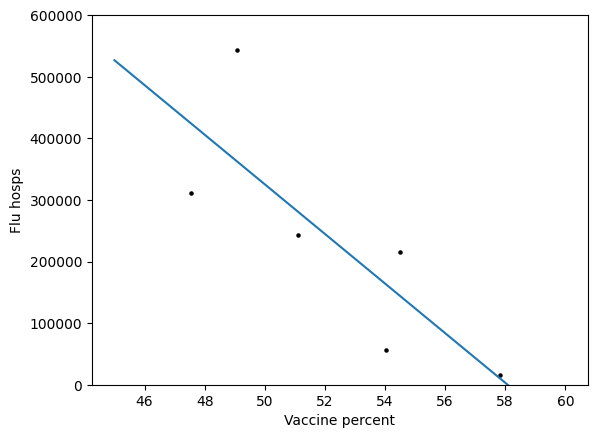

In [98]:
# 7. Answer



## 8. Relationship between the MVN and Linear Regression

Given a vector $[V , F]^{T}$ has a MVN distribution, recall that the formula for the conditional density of $F$ given $V$ is 

\begin{align}
    F | V &\sim \text{MVN}\left( \mu_{F | V}, \Sigma_{F | V}  \right) \\ 
    \mu_{F|V} &= \mu_{F} + \Sigma_{FV}\Sigma_{VV}^{-1} (v - \mu_{V}) \\ 
    \Sigma_{F | V} &= \Sigma_{FF} - \Sigma_{FV}\Sigma_{VV}^{-1}\Sigma_{FV}^{T}
\end{align}

where 

\begin{align}
    \mu = \begin{bmatrix}
        \mu_{V} \\ 
        \mu_{F}
    \end{bmatrix}; \; \; 
    \Sigma = \begin{bmatrix}
        \Sigma_{VV} & \Sigma_{VF} \\ 
        \Sigma_{FV} & \Sigma_{FF} \\ 
    \end{bmatrix}
\end{align}

Please compute $\mu_{F|V}$ and $\Sigma_{F|V}$ for a vaccine percentage of 45\%.

In [99]:
# 8. Answer


## 9. MVN and Linear Regression

Why is $\mu_{F|V}$ for a vaccine percentage of 45 and $\beta_{0} + \beta_{1} \times 45$ equal? 